In [42]:
from utils.paths import RAW_DIR
from preprocessing.database_manager import DatabaseManager
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import umap
import hdbscan
from hdbscan import approximate_predict


ANN Data

In [2]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['r','del_r','del_EN','S','VEC']
ann_data_per = ann_data[cols]

Experimental data

In [29]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [30]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)

X_exp = comp_space[['Cu','Ni','Al']].copy()
Xexp = calc.transform(X_exp)
Xexp = Xexp[cols]

In [32]:
# Standarize
scaler = MinMaxScaler()
X_scale = scaler.fit_transform(ann_data_per)

# Apply PCA training set
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Apply PCA new points data
x_exp_scale = scaler.transform(Xexp)
x_exp_pca = pca.transform(x_exp_scale)
df_exp_pca = pd.DataFrame(x_exp_pca, columns=["PC1", "PC2"])

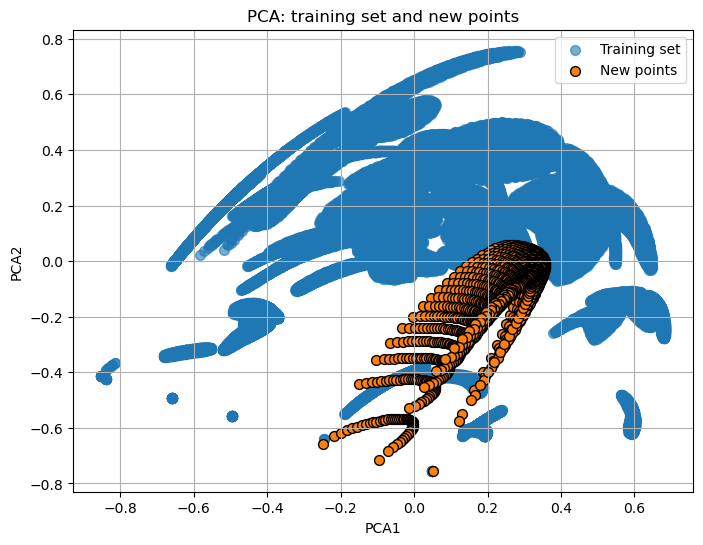

In [33]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_pca["PC1"],
    df_exp_pca["PC2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

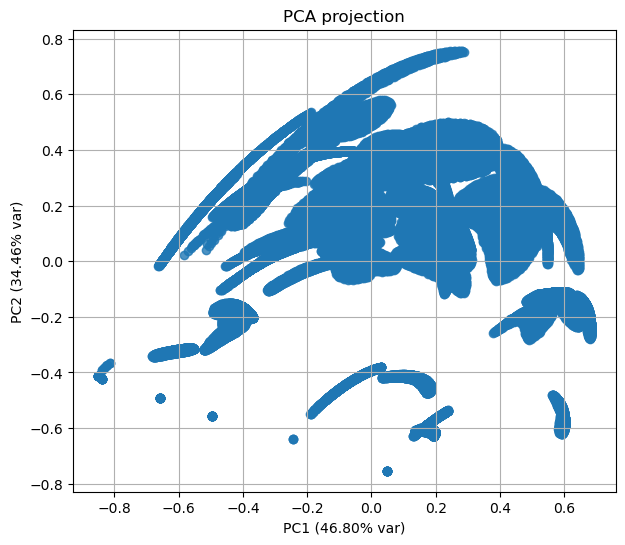

In [8]:
plt.figure(figsize=(7,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA projection")
plt.grid(True)
plt.show()

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


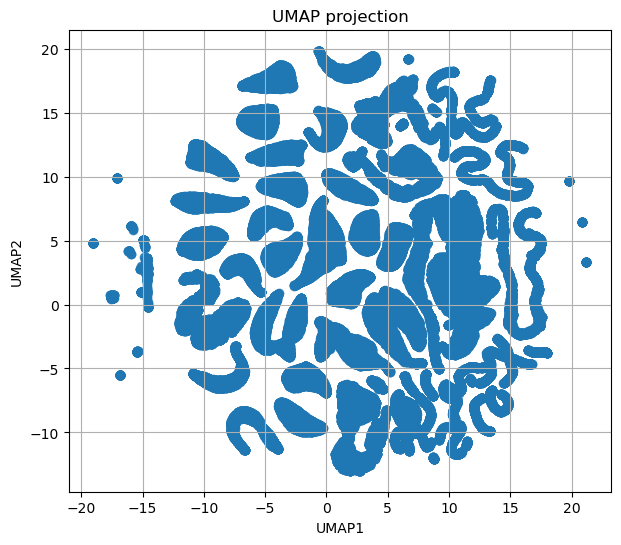

In [34]:
# UMAP model
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Fit and transform
X_umap = reducer.fit_transform(X_scale)

# Put into dataframe
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(df_umap["UMAP1"], df_umap["UMAP2"], alpha=0.8)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projection")
plt.grid(True)
plt.show()

In [35]:
x_exp_scale = scaler.transform(Xexp)
x_exp_umap = reducer.transform(x_exp_scale)
df_exp_umap = pd.DataFrame(x_exp_umap, columns=["UMAP1", "UMAP2"])

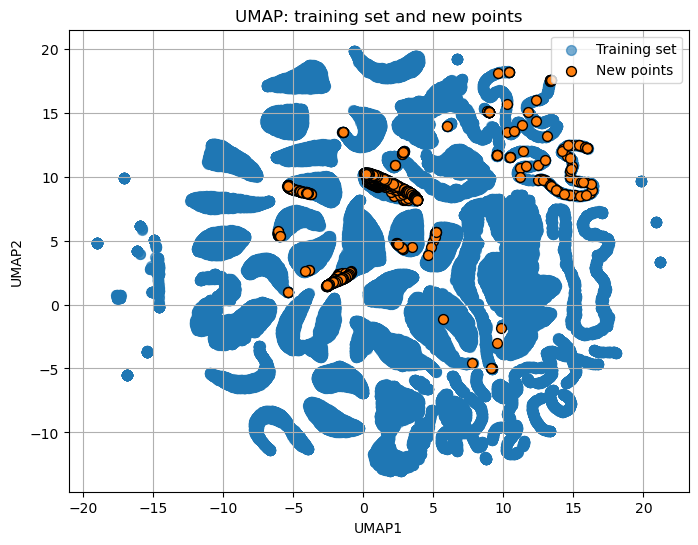

In [38]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_umap["UMAP1"],
    df_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_umap["UMAP1"],
    df_exp_umap["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

Clustering Method

In [52]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
labels = clusterer.fit_predict(X_umap)
df_umap["cluster"] = labels

In [50]:
unique_labels = np.unique(labels)
print(unique_labels)
print("Number of clusters:", len(unique_labels[unique_labels != -1]))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]
Number of clusters: 65
